In [19]:
import pandas as pd
import os, subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown

os.makedirs("dataset/bih_dataset", exist_ok=True)
CLEAN = "dataset/bih_dataset/bih_hourly_clean.csv"
if not os.path.exists(CLEAN):
    gdown.download(id="1QyfzghimgyRhQ735k42JetDEoK5kfGZJ", output=CLEAN, quiet=False)

In [ ]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown
gdown.download_folder(id="1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE", output="shared", quiet=True)
sys.path.append("shared")
import bih_shared as bs

groups = bs.load_groups("shared")
coords = bs.load_coords("shared")
dist   = pd.read_csv("shared/station_distance_km.csv", index_col=0)
panel  = bs.load_panel(CLEAN, "shared")
wins   = bs.load_windows("shared")

In [21]:
print(len(panel), "series")
k = next(iter(panel))
print(k, panel[k].shape, panel[k].y.notna().sum())

107 series
('Ambasada', 'pm25') (35064, 2) 17442


In [22]:
s = panel[('Ambasada', 'pm25')]
real = s.y.notna()
print(real.groupby(real.index.year).mean())

2021    0.995205
2022    0.995776
2023    0.000114
2024    0.000000
Name: y, dtype: float64


In [23]:
print((wins.station == "Ambasada").sum(), "windows for Ambasada")
print(wins[wins.station == "Ambasada"].pollutant.unique())

0 windows for Ambasada
[]


In [24]:
for (st, p), s in panel.items():
    yearly = s.y.notna().groupby(s.index.year).mean()
    if yearly.get(2021, 0) > 0.5 and yearly.get(2024, 1) < 0.05:
        print(st, p, dict(yearly.round(2)))

Ambasada pm25 {2021: np.float64(1.0), 2022: np.float64(1.0), 2023: np.float64(0.0), 2024: np.float64(0.0)}
Ilidza co {2021: np.float64(0.72), 2022: np.float64(0.0), 2023: np.float64(0.0), 2024: np.float64(0.0)}
Prijedor pm10 {2021: np.float64(0.94), 2022: np.float64(0.29), 2023: np.float64(0.59), 2024: np.float64(0.0)}
Prijedor pm25 {2021: np.float64(0.93), 2022: np.float64(0.27), 2023: np.float64(0.53), 2024: np.float64(0.0)}
Tuzla-BKC o3 {2021: np.float64(0.55), 2022: np.float64(0.7), 2023: np.float64(0.0), 2024: np.float64(0.0)}
Ugljevik pm10 {2021: np.float64(0.85), 2022: np.float64(0.93), 2023: np.float64(0.25), 2024: np.float64(0.0)}


In [25]:
scorable = set(zip(wins.station, wins.pollutant))
dead_2024 = [(st, p) for (st, p), s in panel.items()
             if s.y.notna().to_numpy()[s.index.year == 2024].mean() < 0.05
             and (st, p) not in scorable]

## Inspect the shared coordinate table

Before building edges, confirm what columns `station_coords.csv` actually has - the paper's
`same land use` / `same source` edges map onto whatever categorical column we have here
(likely the FHZ register's `type` field: Urbana, Industrijska, Urbano pozadinska, etc.).

In [26]:
print(coords.columns.tolist())
coords.head()


['source', 'city', 'station', 'lat', 'lon', 'elev_m', 'station_type', 'code', 'precision']


,source,city,station,lat,lon,elev_m,station_type,code,precision
0,fhz,Bihac,Bihac,44.8070,15.8660,244.0,Urbano pozadinska,BA0058A,official
1,fhz,Livno,Livno,43.8220,17.0010,806.0,Urbano pozadinska,BA0057A,official
2,fhz,Mostar,Mostar,43.3480,17.7940,97.0,Urbano pozadinska,BA0067A,official
3,fhz,Sarajevo,Ambasada,43.8566,18.4004,540.0,unknown,NaN,published
4,fhz,Sarajevo,Bjelave,43.8670,18.4230,635.0,Urbano pozadinska,BA0029A,official


## 1. Freeze the station-pollutant partitions we'll actually train on

Reuse `station_groups.json` ("never"/"sparse"/"ok") instead of the paper's exhaustive
pollutant-combination grid search - with only 6 pollutants (vs. their 9), the natural
capability groups are a small enough set that we don't need to search over every subset.

Start `ok`-only. Widen to include `sparse` stations later if a partition is too small to train.

Also fold in the dead-by-2024 check from earlier: a station stays in a partition (useful as
graph context / training signal) but is excluded from anything we report as validation.

In [27]:
POLLUTANTS = ["pm10", "pm25", "so2", "no2", "o3", "co"]

def get_target_stations(target, include_sparse=False):
    allowed = {"ok"} | ({"sparse"} if include_sparse else set())
    return [st for st, pmap in groups["by_station"].items() if pmap.get(target) in allowed]

pm10_stations = get_target_stations("pm10")
pm25_stations = get_target_stations("pm25")

print(f"Stations capable of PM10: {len(pm10_stations)}")
print(f"Stations capable of PM2.5: {len(pm25_stations)}")

Stations capable of PM10: 16
Stations capable of PM2.5: 12


In [28]:
# scorable/dead_2024 already computed above (cell 7) - reuse it here.
# Add a per-station-pollutant lookup so a partition's dataset builder can mark
# which nodes are eval-eligible in 2024 without recomputing this every time.
scorable_by_station_pollutant = scorable   # set of (station, pollutant) with real eval windows

print(f"{len(scorable_by_station_pollutant):,} scorable (station, pollutant) series")
print(f"{len(dead_2024)} series excluded from scoring (dead before/during 2024):")
for st, p in dead_2024:
    print(f"  {st:14s} {p}")


98 scorable (station, pollutant) series
9 series excluded from scoring (dead before/during 2024):
  Ambasada       pm25
  Doboj          co
  Hadzici        pm25
  Ilidza         co
  Prijedor       pm10
  Prijedor       pm25
  Tuzla-BKC      o3
  Tuzla-BKC      co
  Ugljevik       pm10


## 2. Build the graph edges

Two edge types, mirroring the paper's `close-to` and `same land use`/`same source` -
collapsed into one `same_type` edge since our register's `type` field (Urbana, Industrijska,
Urbano pozadinska, ...) already conflates land use and likely pollution source.

`close_to` is k-nearest-neighbour by great-circle distance (from `station_distance_km.csv`),
not fully connected - keeps the graph sparse as station count grows.

In [38]:
import torch
import numpy as np

def build_edges(stations, dist_df, coords_df, k=3, max_km=20, min_degree=1):
    """'close_to' edges: restricted to local clusters (max 20km) to avoid noisy distant pairs.
    'same_type' edges: shares the land-use/source category.
    """
    idx = {s: i for i, s in enumerate(stations)}
    sub = dist_df.loc[stations, stations]

    close_src, close_dst, close_w = [], [], []
    for s in stations:
        neighbors = sub[s].drop(s).sort_values()
        within = neighbors[neighbors <= max_km]
        if len(within) < min_degree:
            within = neighbors.head(min_degree)
        within = within.head(k)
        for t, d in within.items():
            close_src.append(idx[s]); close_dst.append(idx[t])
            close_w.append(1.0 / (1.0 + d))

    type_col = "station_type" if "station_type" in coords_df.columns else None
    same_src, same_dst = [], []
    if type_col:
        type_map = coords_df.set_index("station")[type_col].to_dict()
        for s in stations:
            for t in stations:
                ts, tt = type_map.get(s), type_map.get(t)
                if s != t and ts is not None and ts == tt and ts != "unknown":
                    same_src.append(idx[s]); same_dst.append(idx[t])

    edge_index_dict = {
        ("station", "close_to", "station"): torch.tensor([close_src, close_dst], dtype=torch.long),
        ("station", "same_type", "station"): torch.tensor([same_src, same_dst], dtype=torch.long)
                                                if same_src else torch.empty((2, 0), dtype=torch.long),
    }
    edge_weight = {("station", "close_to", "station"): torch.tensor(close_w, dtype=torch.float)}
    return edge_index_dict, edge_weight, idx

## 2. Build the graph edges

Two edge types, mirroring the paper's `close-to` and `same land use`/`same source` -
collapsed into one `same_type` edge since our register's `type` field (Urbana, Industrijska,
Urbano pozadinska, ...) already conflates land use and likely pollution source.

`close_to` now uses a **distance threshold**, not pure k-NN - the EDA (`gnn_eda.ipynb`) showed
correlation drops sharply past ~30-50km, and with small partitions (6-8 stations), a fixed
`k=5` was effectively fully-connecting stations regardless of whether they're actually related
(e.g. Trebinje-Banja Luka, ~280km apart, got an edge just to fill k slots). A `max_km` cutoff
with a `min_degree` fallback (so no station ends up fully isolated) fixes that.


In [41]:
import torch.optim as optim
import matplotlib.pyplot as plt

def batch_edge_index(edge_index_dict, n_nodes, batch_size, device):
    out = {}
    for et, ei in edge_index_dict.items():
        if ei.numel() == 0:
            out[et] = ei.to(device); continue
        out[et] = torch.cat([ei + b * n_nodes for b in range(batch_size)], dim=1).to(device)
    return out

def run_partition_pollutant(target, aux, stations, epochs=30, patience=5, batch=32):
    pollutants = [target] + [p for p in aux if p != target]
    target_col = pollutants.index(target)

    edge_index_dict, edge_weight, idx = build_edges(stations, dist, coords, k=5, max_km=50, min_degree=2)
    full_index, pol_arr, pol_filled = build_partition_tensor(stations, pollutants, panel, idx)
    met_arr = load_met_tensor(stations, MET, full_index)
    cal_arr = calendar_tensor(full_index, len(stations))

    arr = np.concatenate([pol_arr, met_arr, cal_arr], axis=-1)
    filled_full = np.concatenate([
        pol_filled, np.zeros(met_arr.shape, dtype=bool), np.zeros(cal_arr.shape, dtype=bool)
    ], axis=-1)

    train_mask_idx = full_index <= TRAIN_END

    # SAFE NORMALIZATION: Handle entirely missing auxiliary columns
    mu = np.nanmean(arr[train_mask_idx], axis=(0, 1), keepdims=True)
    sigma = np.nanstd(arr[train_mask_idx], axis=(0, 1), keepdims=True) + 1e-6
    mu = np.nan_to_num(mu, nan=0.0)
    sigma = np.nan_to_num(sigma, nan=1.0)

    arr_n = (arr - mu) / sigma
    arr_n = np.nan_to_num(arr_n, nan=0.0) # Zero out any remaining missing data

    train_origins = pd.date_range(full_index.min() + pd.Timedelta(hours=CONTEXT),
                                   TRAIN_END, freq=f"{split['origin_stride_hours']}h")
    val_origins = wins[(wins.station.isin(stations)) & (wins.pollutant == target)].origin.unique()

    train_windows = make_windows(full_index, arr_n, filled_full, train_origins)
    val_windows   = make_windows(full_index, arr_n, filled_full, val_origins)

    scale = {}
    for st in stations:
        s = panel.get((st, target))
        if s is None: continue
        y = s.y.where(~s.filled)
        y = y[y.index <= TRAIN_END]
        sc = (y - y.shift(24)).abs().mean()
        scale[st] = sc if sc and sc > 0 else np.nan

    N = len(stations)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TemporalHeteroGNN(in_dim=arr_n.shape[-1], num_nodes=N, hidden=64, heads=4, dropout=0.3).to(device)
    opt = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
    node_ids = torch.arange(N, device=device).repeat(batch)
    batched_edges = batch_edge_index(edge_index_dict, N, batch, device)

    def run_epoch(windows, train=True):
        model.train(train)
        if train: np.random.shuffle(windows)
        total_loss, n_seen = 0.0, 0
        n_full_batches = len(windows) // batch
        for bi in range(n_full_batches):
            b_ = windows[bi*batch:(bi+1)*batch]
            xs    = np.stack([w[0] for w in b_]).transpose(1, 0, 2, 3)
            ys    = np.stack([w[1] for w in b_])
            reals = np.stack([w[2] for w in b_])
            T, B, Nn, F = xs.shape
            x_t    = torch.nan_to_num(torch.tensor(xs, dtype=torch.float32), nan=0.0).to(device).reshape(T, B*Nn, F)
            y_t    = torch.tensor(ys[:, :, target_col], dtype=torch.float32).reshape(-1).to(device)
            mask_t = torch.tensor(reals[:, :, target_col]).reshape(-1).to(device)
            if mask_t.sum() == 0: continue
            with torch.set_grad_enabled(train):
                pred = model(x_t, batched_edges, node_ids)
                loss = ((pred[mask_t] - y_t[mask_t]) ** 2).mean()
                if train:
                    opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item() * mask_t.sum().item()
            n_seen += mask_t.sum().item()
        return total_loss / max(n_seen, 1)

    best_val, best_state, epochs_since_best = float("inf"), None, 0
    history = {"train": [], "val": []}
    for epoch in range(epochs):
        tr = run_epoch(train_windows, True)
        va = run_epoch(val_windows, False)
        history["train"].append(tr); history["val"].append(va)
        if va < best_val:
            best_val, best_state, epochs_since_best = va, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_since_best += 1
        print(f"[{target}] epoch {epoch+1:2d}/{epochs}  train {tr:.4f}  val {va:.4f}"
              f"{'  *best*' if epochs_since_best == 0 else ''}")
        if epochs_since_best >= patience:
            print(f"[{target}] no val improvement for {patience} epochs - stopping early")
            break
    model.load_state_dict(best_state)

    model.eval()
    station_tile = np.tile(np.array(stations), batch)
    mu_t, sigma_t = float(mu.ravel()[target_col]), float(sigma.ravel()[target_col])
    rows = []
    with torch.no_grad():
        for bi in range(len(val_windows) // batch):
            b_ = val_windows[bi*batch:(bi+1)*batch]
            xs    = np.stack([w[0] for w in b_]).transpose(1, 0, 2, 3)
            ys    = np.stack([w[1] for w in b_])
            reals = np.stack([w[2] for w in b_])
            T, B, Nn, F = xs.shape
            x_t = torch.nan_to_num(torch.tensor(xs, dtype=torch.float32), nan=0.0).to(device).reshape(T, B*Nn, F)
            pred = model(x_t, batched_edges, node_ids).cpu().numpy().reshape(-1)
            pred_phys  = np.clip(pred * sigma_t + mu_t, 0, None)
            truth_phys = (ys[:, :, target_col] * sigma_t + mu_t).reshape(-1)
            real_flat  = reals[:, :, target_col].reshape(-1)
            for p_, t_, r_, s_ in zip(pred_phys, truth_phys, real_flat, station_tile):
                if r_:
                    rows.append((s_, p_, t_))

    res = pd.DataFrame(rows, columns=["station", "pred", "truth"])
    res["abs_err"] = (res.pred - res.truth).abs()
    res["scale"] = res.station.map(scale)
    per_station = res.groupby("station").apply(lambda g: pd.Series({
        "n": len(g), "mae": g.abs_err.mean(), "rmse": np.sqrt((g.abs_err ** 2).mean()),
        "mase": (g.abs_err / g.scale).mean(),
    }))
    overall = pd.Series({
        "n": len(res), "mae": res.abs_err.mean(), "rmse": np.sqrt((res.abs_err ** 2).mean()),
        "mase": (res.abs_err / res.scale).mean(),
    })

    plt.figure(figsize=(6, 4))
    plt.plot(history["train"], label="train"); plt.plot(history["val"], label="val")
    plt.xlabel("epoch"); plt.ylabel("MSE (normalized units)")
    plt.title(f"{target} - {len(stations)} stations"); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return {"model": model, "history": history, "per_station": per_station, "overall": overall}

## 3. Model - ConvLSTM -> Dense/ReLU -> GAT -> Dense/ReLU

Same 4-layer shape as the paper (sec. 3.4), simplified to one node type (`station`) with two
edge types instead of their three node types. `HeteroConv` still does the job of summing
per-edge-type contributions into each node's embedding at every layer.

In [30]:
!pip install torch_geometric

In [42]:
import torch.nn as nn
from torch_geometric.nn import HeteroConv, ChebConv, GATConv

class TemporalHeteroGNN(nn.Module):
    """ConvLSTM -> Dense/ReLU -> GAT -> Residual Dense/ReLU.
    Includes a direct residual link from the station's temporal state (h) to the final prediction
    to prevent spatial aggregation from masking the station's own temporal signal.
    """
    def __init__(self, in_dim, num_nodes, hidden=64, heads=4, K=2, out_dim=1, dropout=0.3, embed_dim=16):
        super().__init__()
        self.hidden = hidden
        self.node_embed = nn.Embedding(num_nodes, embed_dim)
        conv_in_dim = in_dim + embed_dim

        self.conv1 = HeteroConv({
            ("station", "close_to", "station"): ChebConv(conv_in_dim, hidden, K=K),
            ("station", "same_type", "station"): ChebConv(conv_in_dim, hidden, K=K),
        }, aggr="sum")
        self.lstm = nn.LSTMCell(hidden, hidden)

        self.dense2 = nn.Linear(hidden, hidden)
        self.act = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv3 = HeteroConv({
            ("station", "close_to", "station"): GATConv(hidden, hidden, heads=heads),
            ("station", "same_type", "station"): GATConv(hidden, hidden, heads=heads),
        }, aggr="sum")
        self.dropout2 = nn.Dropout(dropout)

        # Residual connection: input dimensions equal GAT output (hidden * heads) + LSTM state (hidden)
        self.dense4 = nn.Linear(hidden * heads + hidden, out_dim)

    def forward(self, x_seq, edge_index_dict, node_ids):
        T, N, _ = x_seq.shape
        emb = self.node_embed(node_ids)
        emb = emb.unsqueeze(0).expand(T, N, -1)
        x_seq = torch.cat([x_seq, emb], dim=-1)

        h = torch.zeros(N, self.hidden, device=x_seq.device)
        c = torch.zeros(N, self.hidden, device=x_seq.device)
        for t in range(T):
            x_dict = {"station": x_seq[t]}
            conv_out = self.conv1(x_dict, edge_index_dict)["station"]
            h, c = self.lstm(conv_out, (h, c))

        z = self.dropout1(self.act(self.dense2(h)))
        att_out = self.conv3({"station": z}, edge_index_dict)["station"]
        att_out = self.dropout2(att_out)

        # Combine spatial graph context (att_out) with station's direct temporal state (h)
        combined = torch.cat([att_out, h], dim=-1)
        return self.dense4(combined).squeeze(-1)

## 4. Dataset builder for one partition

Windows come from `wins` (the frozen `eval_windows.csv`) for validation, and from a plain
sliding window over train (<= 2023-12-31, per `split.json`) for training. Context length is
deliberately ours to choose (the shared split notebook left it open on purpose) - start at
168h (1 week) since that's the minimum guaranteed by `min_real_context_hours_168` in the mask rule.

Node features per timestep: this partition's pollutants + MET features, for every station in
the partition, in a fixed station order (`idx` from `build_edges`).

In [43]:
split = bs.load_split("shared")
TRAIN_END = pd.Timestamp(split["train"]["end"])
HORIZON   = split["horizon_hours"]
CONTEXT   = 168
MET = ["temperature", "humidity", "wind_speed", "wind_u", "wind_v", "pressure"]

def build_partition_tensor(stations, pollutants, panel, idx):
    """Stacks [T_full, N, F] pollutant values, plus a matching `filled` boolean tensor
    (True = interpolated, not a real measurement) so downstream code can exclude filled
    values from ground truth - matches how baseline_metrics.csv was scored (non-_filled
    data only). Using isnan alone was a bug: it let interpolated values count as real targets.
    """
    full_index = panel[next(iter(panel))].index
    T, N, F = len(full_index), len(stations), len(pollutants)
    arr = np.full((T, N, F), np.nan, dtype=np.float32)
    filled = np.zeros((T, N, F), dtype=bool)
    for j, st in enumerate(stations):
        for k, p in enumerate(pollutants):
            if (st, p) in panel:
                s = panel[(st, p)]
                arr[:, j, k] = s.y.to_numpy()
                filled[:, j, k] = getattr(s, "filled", np.zeros(T, dtype=bool))
    return full_index, arr, filled

def calendar_tensor(full_index, n_stations):
    """Hour-of-day + day-of-year as sin/cos pairs, broadcast to every node. The EDA found
    PM2.5/PM10 is strongly seasonal (winter median 0.896 vs summer 0.653 - heating + winter
    inversion signature); MET alone doesn't tell the model 'it's winter'.
    """
    hour = full_index.hour.to_numpy(dtype=np.float32)
    doy  = full_index.dayofyear.to_numpy(dtype=np.float32)
    cal = np.stack([
        np.sin(2 * np.pi * hour / 24), np.cos(2 * np.pi * hour / 24),
        np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25),
    ], axis=1)                                                     # [T, 4]
    return np.repeat(cal[:, None, :], n_stations, axis=1).astype(np.float32)   # [T, N, 4]

def make_windows(full_index, arr, filled, origins, context=CONTEXT, horizon=HORIZON):
    """Returns (x, y, real_mask, origin) tuples. `real_mask` is True only where y is a
    genuine measurement (not NaN, not interpolated) - use this, not isnan alone, anywhere
    y is treated as ground truth (training loss and validation scoring both).
    """
    pos = {t: i for i, t in enumerate(full_index)}
    out = []
    for o in origins:
        if o not in pos:
            continue
        i = pos[o]
        if i - context < 0 or i + horizon > len(full_index):
            continue
        x = arr[i - context:i]
        y = arr[i + horizon - 1]
        real = (~np.isnan(y)) & (~filled[i + horizon - 1])
        out.append((x, y, real, o))
    return out


## 5. Train one partition - single target pollutant, worked example

The paper found most of their per-pollutant GNNs ended up using only 1-2 auxiliary pollutants
despite starting with subsets of up to 5. Start narrow: target pollutant + its strongest
correlate (PM10 for PM2.5, as in the earlier EDA), not the full partition capability set.
Widen only if validation error demands it - matches the paper's actual finding, not just a
shortcut.

In [44]:
def load_met_tensor(stations, met_vars, full_index):
    raw = pd.read_csv(CLEAN, usecols=["station", "datetime"] + met_vars, parse_dates=["datetime"])
    raw = raw[raw.station.isin(stations)]
    T, N, M = len(full_index), len(stations), len(met_vars)
    arr = np.full((T, N, M), np.nan, dtype=np.float32)
    for j, st in enumerate(stations):
        sub = raw[raw.station == st].set_index("datetime").reindex(full_index)
        for k, m in enumerate(met_vars):
            arr[:, j, k] = sub[m].to_numpy()
    return arr

# EDA-confirmed correlated Sarajevo cluster - see gnn_eda.ipynb for why this beats picking
# 'largest capability partition' blindly.
PRIORITY_STATIONS = ["Bjelave", "Vijecnica", "Otoka", "Ilidza", "Vogosca", "Ilijas", "Hadzici"]

def priority_overlap(sts):
    return len(set(sts) & set(PRIORITY_STATIONS))

caps, full_stations = max(partitions.items(), key=lambda kv: (priority_overlap(kv[1]), len(kv[1])))
stations = [s for s in full_stations if s in PRIORITY_STATIONS] or full_stations
print(f"partition capability: {caps}")
print(f"  full partition ({len(full_stations)} stations): {full_stations}")
print(f"  piloting on correlated Sarajevo cluster ({len(stations)} stations): {stations}")


partition capability: ('no2', 'pm10', 'pm25', 'so2')
  full partition (2 stations): ['Ilidza', 'Vogosca']
  piloting on correlated Sarajevo cluster (2 stations): ['Ilidza', 'Vogosca']


In [45]:
import torch.optim as optim
import matplotlib.pyplot as plt

def batch_edge_index(edge_index_dict, n_nodes, batch_size, device):
    out = {}
    for et, ei in edge_index_dict.items():
        if ei.numel() == 0:
            out[et] = ei.to(device); continue
        out[et] = torch.cat([ei + b * n_nodes for b in range(batch_size)], dim=1).to(device)
    return out

def run_partition_pollutant(target, aux, stations, epochs=30, patience=5, batch=32):
    pollutants = [target] + [p for p in aux if p != target]
    target_col = pollutants.index(target)

    # Tightened distance threshold (max_km=20) and k=3
    edge_index_dict, edge_weight, idx = build_edges(stations, dist, coords, k=3, max_km=20, min_degree=1)
    full_index, pol_arr, pol_filled = build_partition_tensor(stations, pollutants, panel, idx)
    met_arr = load_met_tensor(stations, MET, full_index)
    cal_arr = calendar_tensor(full_index, len(stations))

    arr = np.concatenate([pol_arr, met_arr, cal_arr], axis=-1)
    filled_full = np.concatenate([
        pol_filled, np.zeros(met_arr.shape, dtype=bool), np.zeros(cal_arr.shape, dtype=bool)
    ], axis=-1)

    train_mask_idx = full_index <= TRAIN_END
    mu = np.nanmean(arr[train_mask_idx], axis=(0, 1), keepdims=True)
    sigma = np.nanstd(arr[train_mask_idx], axis=(0, 1), keepdims=True) + 1e-6
    mu = np.nan_to_num(mu, nan=0.0)
    sigma = np.nan_to_num(sigma, nan=1.0)

    arr_n = (arr - mu) / sigma
    arr_n = np.nan_to_num(arr_n, nan=0.0)

    train_origins = pd.date_range(full_index.min() + pd.Timedelta(hours=CONTEXT),
                                   TRAIN_END, freq=f"{split['origin_stride_hours']}h")
    val_origins = wins[(wins.station.isin(stations)) & (wins.pollutant == target)].origin.unique()

    train_windows = make_windows(full_index, arr_n, filled_full, train_origins)
    val_windows   = make_windows(full_index, arr_n, filled_full, val_origins)

    scale = {}
    for st in stations:
        s = panel.get((st, target))
        if s is None: continue
        y = s.y.where(~s.filled)
        y = y[y.index <= TRAIN_END]
        sc = (y - y.shift(24)).abs().mean()
        scale[st] = sc if sc and sc > 0 else np.nan

    N = len(stations)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TemporalHeteroGNN(in_dim=arr_n.shape[-1], num_nodes=N, hidden=64, heads=4, dropout=0.3).to(device)
    opt = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
    node_ids = torch.arange(N, device=device).repeat(batch)
    batched_edges = batch_edge_index(edge_index_dict, N, batch, device)

    def run_epoch(windows, train=True):
        model.train(train)
        if train: np.random.shuffle(windows)
        total_loss, n_seen = 0.0, 0
        n_full_batches = len(windows) // batch
        for bi in range(n_full_batches):
            b_ = windows[bi*batch:(bi+1)*batch]
            xs    = np.stack([w[0] for w in b_]).transpose(1, 0, 2, 3)
            ys    = np.stack([w[1] for w in b_])
            reals = np.stack([w[2] for w in b_])
            T, B, Nn, F = xs.shape
            x_t    = torch.nan_to_num(torch.tensor(xs, dtype=torch.float32), nan=0.0).to(device).reshape(T, B*Nn, F)
            y_t    = torch.tensor(ys[:, :, target_col], dtype=torch.float32).reshape(-1).to(device)
            mask_t = torch.tensor(reals[:, :, target_col]).reshape(-1).to(device)
            if mask_t.sum() == 0: continue
            with torch.set_grad_enabled(train):
                pred = model(x_t, batched_edges, node_ids)
                loss = ((pred[mask_t] - y_t[mask_t]) ** 2).mean()
                if train:
                    opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item() * mask_t.sum().item()
            n_seen += mask_t.sum().item()
        return total_loss / max(n_seen, 1)

    best_val, best_state, epochs_since_best = float("inf"), None, 0
    history = {"train": [], "val": []}
    for epoch in range(epochs):
        tr = run_epoch(train_windows, True)
        va = run_epoch(val_windows, False)
        history["train"].append(tr); history["val"].append(va)
        if va < best_val:
            best_val, best_state, epochs_since_best = va, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_since_best += 1
        print(f"[{target}] epoch {epoch+1:2d}/{epochs}  train {tr:.4f}  val {va:.4f}"
              f"{'  *best*' if epochs_since_best == 0 else ''}")
        if epochs_since_best >= patience:
            print(f"[{target}] no val improvement for {patience} epochs - stopping early")
            break
    model.load_state_dict(best_state)

    model.eval()
    station_tile = np.tile(np.array(stations), batch)
    mu_t, sigma_t = float(mu.ravel()[target_col]), float(sigma.ravel()[target_col])
    rows = []
    with torch.no_grad():
        for bi in range(len(val_windows) // batch):
            b_ = val_windows[bi*batch:(bi+1)*batch]
            xs    = np.stack([w[0] for w in b_]).transpose(1, 0, 2, 3)
            ys    = np.stack([w[1] for w in b_])
            reals = np.stack([w[2] for w in b_])
            T, B, Nn, F = xs.shape
            x_t = torch.nan_to_num(torch.tensor(xs, dtype=torch.float32), nan=0.0).to(device).reshape(T, B*Nn, F)
            pred = model(x_t, batched_edges, node_ids).cpu().numpy().reshape(-1)
            pred_phys  = np.clip(pred * sigma_t + mu_t, 0, None)
            truth_phys = (ys[:, :, target_col] * sigma_t + mu_t).reshape(-1)
            real_flat  = reals[:, :, target_col].reshape(-1)
            for p_, t_, r_, s_ in zip(pred_phys, truth_phys, real_flat, station_tile):
                if r_:
                    rows.append((s_, p_, t_))

    res = pd.DataFrame(rows, columns=["station", "pred", "truth"])
    res["abs_err"] = (res.pred - res.truth).abs()
    res["scale"] = res.station.map(scale)

    # Fixed DeprecationWarning by adding include_groups=False
    per_station = res.groupby("station").apply(lambda g: pd.Series({
        "n": len(g), "mae": g.abs_err.mean(), "rmse": np.sqrt((g.abs_err ** 2).mean()),
        "mase": (g.abs_err / g.scale).mean(),
    }), include_groups=False)

    overall = pd.Series({
        "n": len(res), "mae": res.abs_err.mean(), "rmse": np.sqrt((res.abs_err ** 2).mean()),
        "mase": (res.abs_err / res.scale).mean(),
    })

    plt.figure(figsize=(6, 4))
    plt.plot(history["train"], label="train"); plt.plot(history["val"], label="val")
    plt.xlabel("epoch"); plt.ylabel("MSE (normalized units)")
    plt.title(f"{target} - {len(stations)} stations"); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return {"model": model, "history": history, "per_station": per_station, "overall": overall}

## 6. Score - MASE (per station), both PM2.5 and PM10

Reporting MASE now, not just MAE/RMSE, so results line up directly with `baseline_metrics.csv`
(`persistence_t24`) and with the Chronos MASE-by-station table the team shared
(range ~0.70-0.99, mean gain ~20-25% over `persistence_t24`). That range is the actual bar to
clear here, not just 'beats persistence in MAE'.

Also running PM10 as its own target for the first time - until now only PM2.5 was ever
trained, with PM10 folded in as an input feature. `run_partition_pollutant` makes both a
one-line call so this is easy to extend to more pollutants/partitions later.

[pm25] epoch  1/30  train 0.8653  val 0.5689  *best*
[pm25] epoch  2/30  train 0.6707  val 0.5623  *best*
[pm25] epoch  3/30  train 0.6493  val 0.5413  *best*
[pm25] epoch  4/30  train 0.6245  val 0.5383  *best*
[pm25] epoch  5/30  train 0.5991  val 0.5300  *best*
[pm25] epoch  6/30  train 0.6030  val 0.5103  *best*
[pm25] epoch  7/30  train 0.5738  val 0.5223
[pm25] epoch  8/30  train 0.5769  val 0.5168
[pm25] epoch  9/30  train 0.5648  val 0.5096  *best*
[pm25] epoch 10/30  train 0.5606  val 0.5006  *best*
[pm25] epoch 11/30  train 0.5423  val 0.4982  *best*
[pm25] epoch 12/30  train 0.5318  val 0.5071
[pm25] epoch 13/30  train 0.5285  val 0.5267
[pm25] epoch 14/30  train 0.5208  val 0.5054
[pm25] epoch 15/30  train 0.5014  val 0.4943  *best*
[pm25] epoch 16/30  train 0.5214  val 0.5413
[pm25] epoch 17/30  train 0.5035  val 0.5043
[pm25] epoch 18/30  train 0.4830  val 0.5145
[pm25] epoch 19/30  train 0.4778  val 0.5148
[pm25] epoch 20/30  train 0.4671  val 0.5198
[pm25] no val improv

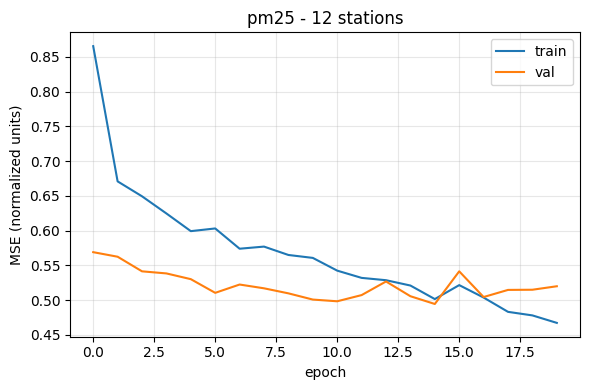

[pm10] epoch  1/30  train 0.8099  val 0.7099  *best*
[pm10] epoch  2/30  train 0.6327  val 0.6825  *best*
[pm10] epoch  3/30  train 0.5995  val 0.6681  *best*
[pm10] epoch  4/30  train 0.5714  val 0.6586  *best*
[pm10] epoch  5/30  train 0.5851  val 0.6293  *best*
[pm10] epoch  6/30  train 0.5741  val 0.6320
[pm10] epoch  7/30  train 0.5400  val 0.6065  *best*
[pm10] epoch  8/30  train 0.5311  val 0.6191
[pm10] epoch  9/30  train 0.5315  val 0.6053  *best*
[pm10] epoch 10/30  train 0.5200  val 0.6284
[pm10] epoch 11/30  train 0.5115  val 0.5988  *best*
[pm10] epoch 12/30  train 0.5159  val 0.6020
[pm10] epoch 13/30  train 0.5561  val 0.6522
[pm10] epoch 14/30  train 0.5099  val 0.5873  *best*
[pm10] epoch 15/30  train 0.4858  val 0.6005
[pm10] epoch 16/30  train 0.4876  val 0.6029
[pm10] epoch 17/30  train 0.4899  val 0.5969
[pm10] epoch 18/30  train 0.4787  val 0.6291
[pm10] epoch 19/30  train 0.4900  val 0.6116
[pm10] no val improvement for 5 epochs - stopping early


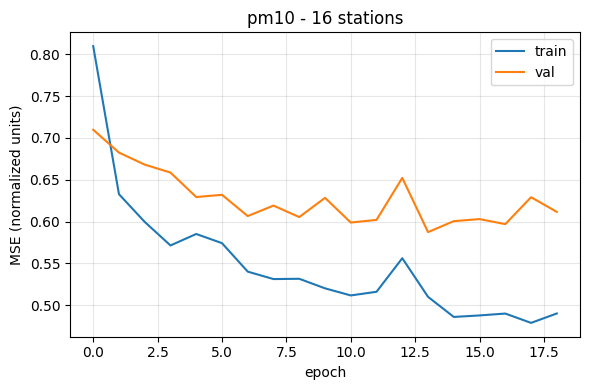


=== PM2.5 - overall ===
n       4211.000
mae       13.601
rmse      25.200
mase       1.023
dtype: float64

=== PM10 - overall ===
n       5613.000
mae       16.072
rmse      28.292
mase       0.970
dtype: float64


In [46]:
# Predict PM2.5 using all stations capable of reporting PM2.5
result_pm25 = run_partition_pollutant("pm25", ["pm10"], pm25_stations)

# Predict PM10 using all stations capable of reporting PM10
result_pm10 = run_partition_pollutant("pm10", ["pm25"], pm10_stations)

print("\n=== PM2.5 - overall ===")
print(result_pm25["overall"].round(3))
print("\n=== PM10 - overall ===")
print(result_pm10["overall"].round(3))

## Next steps

1. **Compare MASE directly against the Chronos table** (range ~0.70-0.99, mean ~20-25% gain
   over `persistence_t24`). If the GNN's per-station MASE clears that on this well-correlated
   cluster, that's real evidence the spatial structure adds value beyond what a strong
   univariate foundation model already captures. If it doesn't, that's a legitimate finding
   too - report it rather than only chasing a win.
2. Loop `run_partition_pollutant` over every partition in `partitions`, for both pollutants
   where available - mirrors the paper's `G^Delta_p` set construction, using the natural
   capability groups instead of an exhaustive subset search.
3. For pollutants covered by more than one partition, keep whichever partition scores lower
   MASE for that pollutant (paper's coverage rule).
4. Consider a season-conditioned MASE breakdown (mirrors the Chronos 'MASE BY SEASON' table) -
   the EDA found winter has the strongest, most divergent seasonal signature per station, so a
   single aggregate MASE may hide a lot of season-specific variation.
5. Add the `sparse`-status stations once the `ok`-only pipeline is validated.
6. Write results in the same shape as `baseline_metrics.csv` / the Chronos table
   (`pollutant, station, model, mae, rmse, mase`) so the team's final comparison table can pull
   straight from GNN / xLSTM / Chronos outputs.
